In [16]:
import pandas as pd

print(orders.head())


   Row ID  Order ID Order Date Order Priority  Order Quantity       Sales  \
0       1         3 2010-10-13            Low               6    261.5400   
1      49       293 2012-10-01           High              49  10123.0200   
2      50       293 2012-10-01           High              27    244.5700   
3      80       483 2011-07-10           High              30   4965.7595   
4      85       515 2010-08-28  Not Specified              19    394.2700   

   Discount       Ship Mode     Profit  Unit Price  ...       Customer Name  \
0      0.04     Regular Air  -213.2500       38.94  ...  Muhammed MacIntyre   
1      0.07  Delivery Truck   457.8100      208.16  ...        Barry French   
2      0.01     Regular Air    46.7075        8.69  ...        Barry French   
3      0.08     Regular Air  1198.9710      195.99  ...       Clay Rozendal   
4      0.08     Regular Air    30.9400       21.78  ...      Carlos Soltero   

  Province   Region Customer Segment Product Category  \
0  Nu

                  Region         Sales         Profit
0               Atlantic  2.014248e+06  238960.612930
1  Northwest Territories  8.008473e+05  100653.051900
2                Nunavut  1.163765e+05    2841.117000
3                Ontario  3.063212e+06  346868.581175
4                 Prarie  2.837305e+06  321160.180400
5                 Quebec  1.510195e+06  140426.594746
6                   West  7.195099e+06  594017.152060
7                  Yukon  9.758674e+05   73849.245400


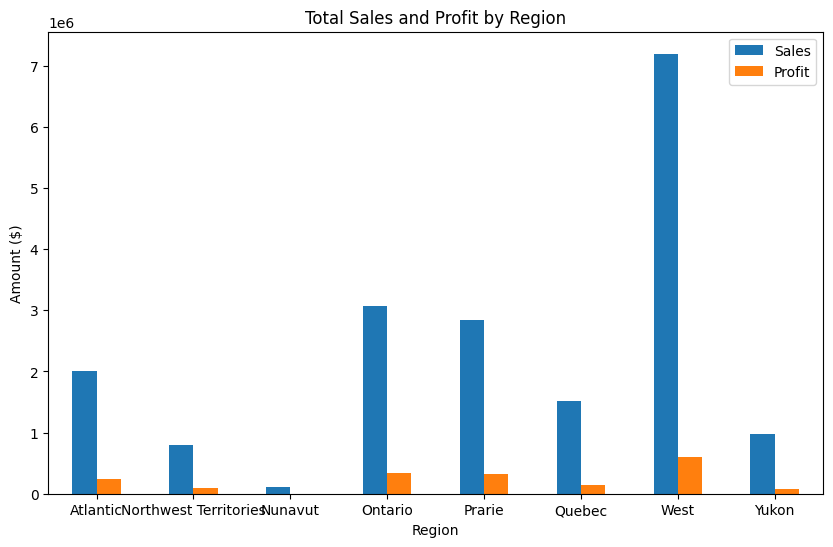

In [17]:
# Question 1: What is the total sales revenue and net profit generated by each region?

import matplotlib.pyplot as plt

# Merge Orders and Users to get the Region data attached to the sales data
merged_data = pd.merge(orders, users, on='Region', how='left')

# Group by region and calculate the sum for Sales and Profit
region_summary = merged_data.groupby('Region')[['Sales', 'Profit']].sum().reset_index()
print(region_summary)

# Create a bar chart using matplotlib
region_summary.plot(x='Region', y=['Sales', 'Profit'], kind='bar', figsize=(10, 6))
plt.title('Total Sales and Profit by Region')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.show()

              Product Sub-Category       Profit
16    Telephones and Communication  316951.6410
9                  Office Machines  307712.9303
1   Binders and Binder Accessories  307413.4180
5                  Copiers and Fax  167361.4640
3               Chairs & Chairmats  149649.7250


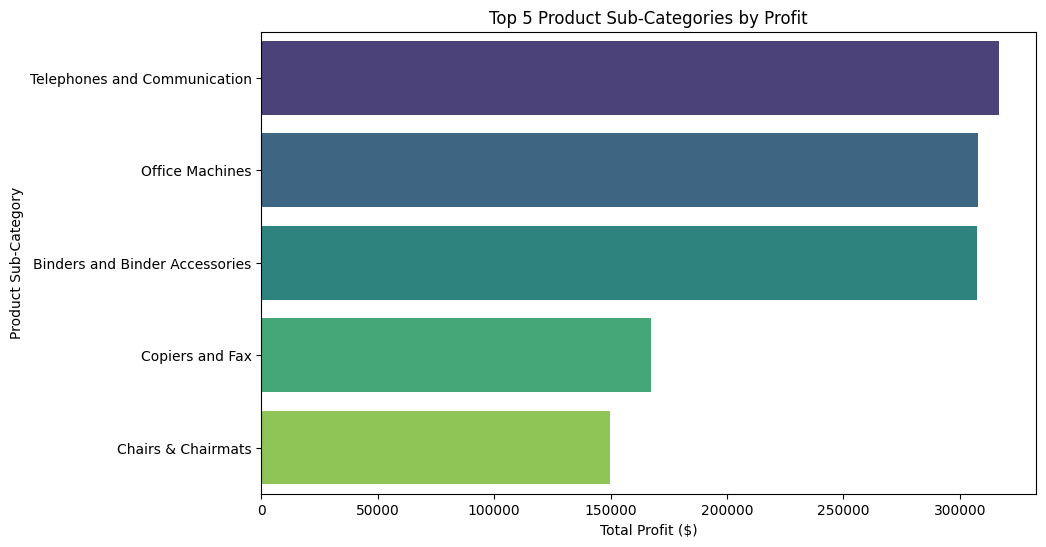

In [21]:
# Question 2: Which top 5 product sub-categories yield the highest profit margins?

import seaborn as sns

# Group by sub-category, sum the profit, sort descending, and take the top 5
top_5_profit = orders.groupby('Product Sub-Category')['Profit'].sum().reset_index()
top_5_profit = top_5_profit.sort_values(by='Profit', ascending=False).head(5)
print(top_5_profit)

# Create a bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(data=top_5_profit, x='Profit', y='Product Sub-Category', hue='Product Sub-Category', palette='viridis', legend=False)
plt.title('Top 5 Product Sub-Categories by Profit')
plt.xlabel('Total Profit ($)')
plt.ylabel('Product Sub-Category')
plt.show()

Average Discount by Segment:
   Customer Segment  Discount
0         Consumer  0.049903
1        Corporate  0.049841
2      Home Office  0.049444
3   Small Business  0.049403


/tmp/ipykernel_1098/2864485532.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_discount, x='Customer Segment', y='Discount', palette='Set2')


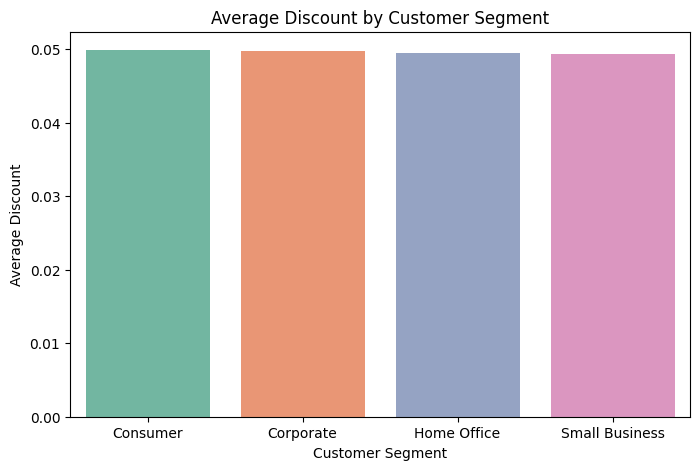

In [19]:
# Question 3: How does the average discount applied vary across different customer segments?
avg_discount = orders.groupby('Customer Segment')['Discount'].mean().reset_index()
print("Average Discount by Segment:\n", avg_discount)

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_discount, x='Customer Segment', y='Discount', palette='Set2')
plt.title('Average Discount by Customer Segment')
plt.ylabel('Average Discount')
plt.show()

Average Shipping Cost:
         Ship Mode  Shipping Cost
0  Delivery Truck      45.350733
1     Express Air       7.986684
2     Regular Air       7.656809


/tmp/ipykernel_1098/122921813.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_shipping, x='Ship Mode', y='Shipping Cost', palette='coolwarm')


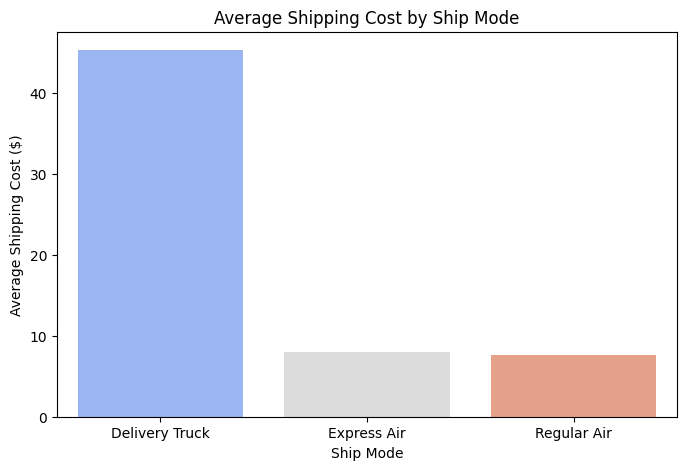

In [20]:
# Question 4: What is the average shipping cost associated with each ship mode?
avg_shipping = orders.groupby('Ship Mode')['Shipping Cost'].mean().reset_index()
print("Average Shipping Cost:\n", avg_shipping)

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_shipping, x='Ship Mode', y='Shipping Cost', palette='coolwarm')
plt.title('Average Shipping Cost by Ship Mode')
plt.ylabel('Average Shipping Cost ($)')
plt.show()

Average Days to Ship:
   Order Priority  Shipping Days
1           High       1.412896
4  Not Specified       1.465909
3         Medium       1.472103
0       Critical       1.515547
2            Low       4.238372


/tmp/ipykernel_1098/4112701609.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_ship_days, x='Order Priority', y='Shipping Days', palette='magma')


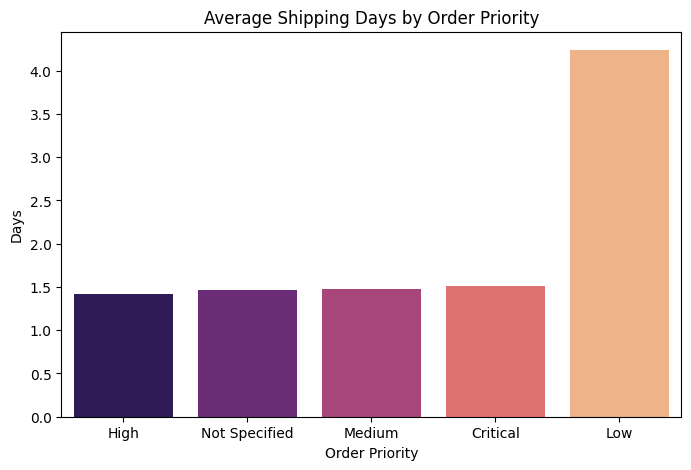

In [22]:
# Question 5: How many days on average does it take for an order to ship based on its order priority?

# Convert date columns to datetime objects
orders['Order Date'] = pd.to_datetime(orders['Order Date'])
orders['Ship Date'] = pd.to_datetime(orders['Ship Date'])

# Calculate the difference in days
orders['Shipping Days'] = (orders['Ship Date'] - orders['Order Date']).dt.days

# Group by Priority
avg_ship_days = orders.groupby('Order Priority')['Shipping Days'].mean().reset_index()
avg_ship_days = avg_ship_days.sort_values('Shipping Days')
print("Average Days to Ship:\n", avg_ship_days)

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_ship_days, x='Order Priority', y='Shipping Days', palette='magma')
plt.title('Average Shipping Days by Order Priority')
plt.ylabel('Days')
plt.show()

Orders per Manager:
    Manager  Order ID
0      Pat      1330
1  William      1330


/tmp/ipykernel_1098/3055450630.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=manager_orders, x='Manager', y='Order ID', palette='pastel')


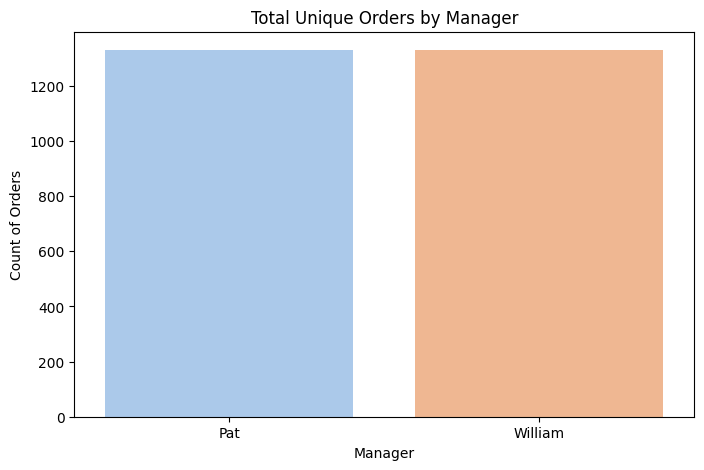

In [23]:
# Question 6: Which regional manager oversees the highest volume of total orders?

# Ensure the tables are merged (using the merged_data from Question 1)
merged_data = pd.merge(orders, users, on='Region', how='left')

# Count unique Order IDs per manager
manager_orders = merged_data.groupby('Manager')['Order ID'].nunique().reset_index()
manager_orders = manager_orders.sort_values(by='Order ID', ascending=False)
print("Orders per Manager:\n", manager_orders)

plt.figure(figsize=(8, 5))
sns.barplot(data=manager_orders, x='Manager', y='Order ID', palette='pastel')
plt.title('Total Unique Orders by Manager')
plt.ylabel('Count of Orders')
plt.show()

Total Losses per Manager:
    Manager        Profit
0      Pat -308287.89497
1  William -308287.89497


/tmp/ipykernel_1098/4169651763.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=manager_losses, x='Manager', y='Profit', palette='Reds_r')


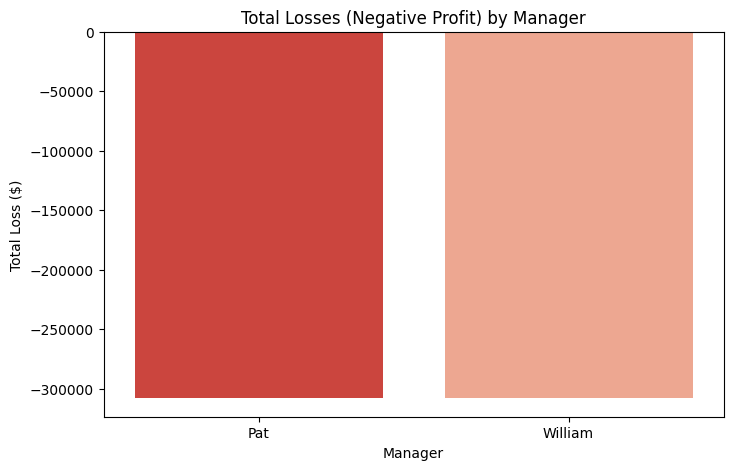

In [24]:
# Question 7: Is there a correlation between the region's manager and the total amount of negative profit (losses) in their territory?

# Filter for rows where profit is negative
losses = merged_data[merged_data['Profit'] < 0]

# Sum the losses per manager
manager_losses = losses.groupby('Manager')['Profit'].sum().reset_index()
print("Total Losses per Manager:\n", manager_losses)

plt.figure(figsize=(8, 5))
sns.barplot(data=manager_losses, x='Manager', y='Profit', palette='Reds_r')
plt.title('Total Losses (Negative Profit) by Manager')
plt.ylabel('Total Loss ($)')
plt.show()

Total Unique Orders: 5496
Returned Orders: 572
Return Percentage: 10.41%


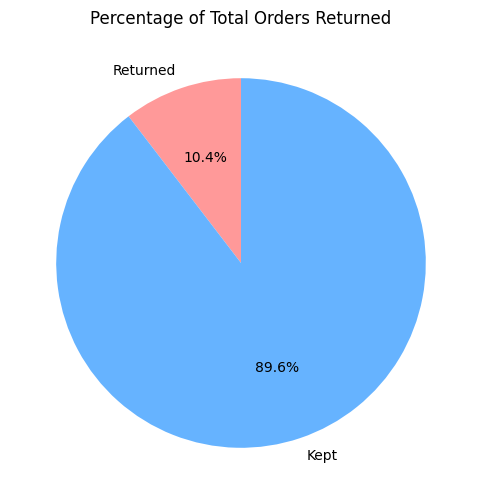

In [25]:
# Question 8: What percentage of total orders result in a return?
total_unique_orders = orders['Order ID'].nunique()
returned_orders_count = returns['Order ID'].nunique()

return_percentage = (returned_orders_count / total_unique_orders) * 100
print(f"Total Unique Orders: {total_unique_orders}")
print(f"Returned Orders: {returned_orders_count}")
print(f"Return Percentage: {return_percentage:.2f}%")

# Create a pie chart
labels = ['Returned', 'Kept']
sizes = [returned_orders_count, total_unique_orders - returned_orders_count]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Percentage of Total Orders Returned')
plt.show()

Returns by Category:
   Product Category  Order ID
1  Office Supplies       363
2       Technology       196
0        Furniture       169


/tmp/ipykernel_1098/4135903794.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=return_by_category, x='Product Category', y='Order ID', palette='muted')


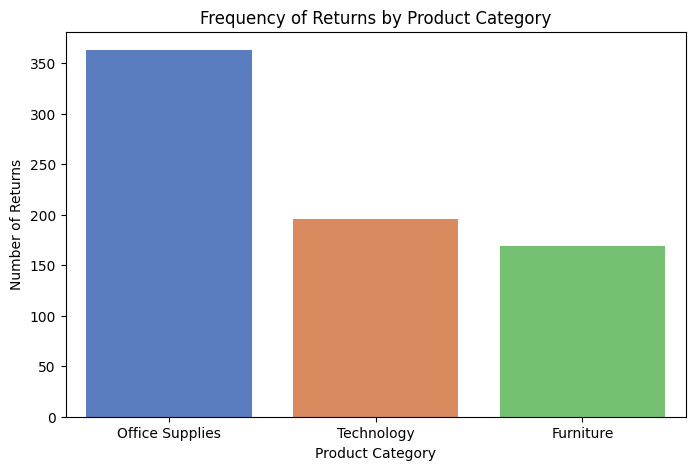

In [26]:
# Question 9: Which specific product category experiences the highest frequency of returns?

# Merge orders with returns to isolate only the returned items
returns_merged = pd.merge(orders, returns, on='Order ID', how='inner')

# Count the unique returned orders per category
return_by_category = returns_merged.groupby('Product Category')['Order ID'].nunique().reset_index()
return_by_category = return_by_category.sort_values(by='Order ID', ascending=False)
print("Returns by Category:\n", return_by_category)

plt.figure(figsize=(8, 5))
sns.barplot(data=return_by_category, x='Product Category', y='Order ID', palette='muted')
plt.title('Frequency of Returns by Product Category')
plt.ylabel('Number of Returns')
plt.show()

Top 10 Customers:
          Customer Name        Sales
261         Emily Phan  117124.4380
218  Deborah Brumfield   97433.1355
659         Roy Skaria   92542.1530
732    Sylvia Foulston   88875.7575
309      Grant Carroll   88417.0025
17     Alejandro Grove   83561.9300
198        Darren Budd   81577.3435
405      Julia Barnett   80044.4520
392         John Lucas   79696.1875
472    Liz MacKendrick   76306.4315


/tmp/ipykernel_1098/3923185415.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_customers, x='Sales', y='Customer Name', palette='Blues_r')


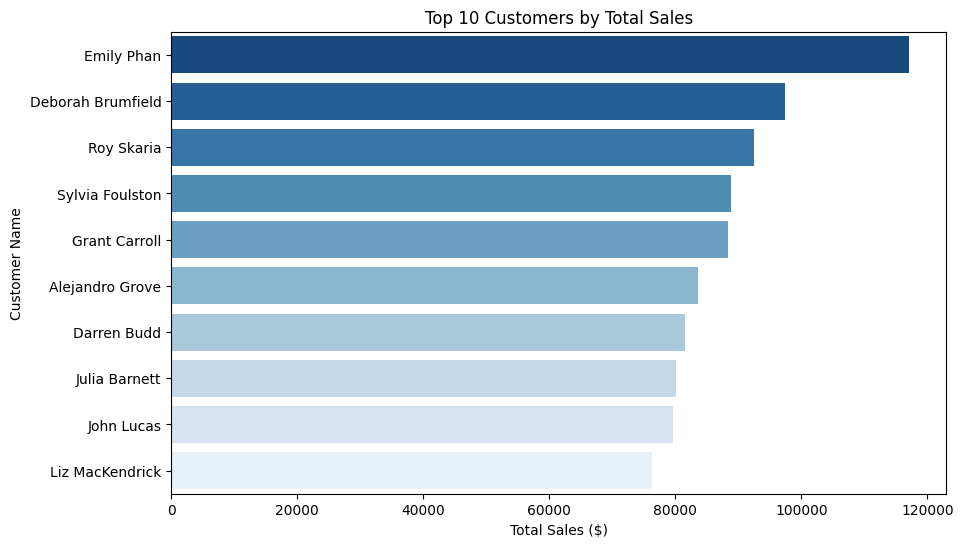

In [27]:
# Question 10: Who are the top 10 most valuable customers based on total sales volume?
top_customers = orders.groupby('Customer Name')['Sales'].sum().reset_index()
top_customers = top_customers.sort_values(by='Sales', ascending=False).head(10)
print("Top 10 Customers:\n", top_customers)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_customers, x='Sales', y='Customer Name', palette='Blues_r')
plt.title('Top 10 Customers by Total Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Customer Name')
plt.show()